MODEL TRAINING:

In [5]:
#Import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [9]:
# Load ML-ready data

ml_data = pd.read_csv("../data/cleaned/epl-ml-ready.csv")

features = ["win_pct", "draw_pct", "loss_pct", "GF", "GA", "GD"]

x = ml_data[features]
y = ml_data["Pos"]

In [10]:
# Train/test split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

Model 1: Linear Regression

In [11]:
# Model 1: Linear Regression

linear_model = LinearRegression()

linear_model.fit(x_train, y_train)

linear_predictions = linear_model.predict(x_test).round().clip(1, 20)

linear_mae = mean_absolute_error(y_test, linear_predictions)

print("Linear Regression MAE:", linear_mae)

Linear Regression MAE: 1.22


Model 2: Random Forest

In [12]:
# Model 2: Random Forest

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train, y_train)

rf_predictions = rf_model.predict(x_test).round().clip(1, 20)

rf_mae = mean_absolute_error(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)

Random Forest MAE: 1.03


In [13]:
# Compare actual vs predicted

comparison = pd.DataFrame({
    "Actual Position": y_test,
    "Predicted Position": rf_predictions
}).reset_index(drop=True)

comparison["Error"] = abs(
    comparison["Actual Position"] - comparison["Predicted Position"]
)

print(comparison.head(20))

    Actual Position  Predicted Position  Error
0                 2                 1.0    1.0
1                14                13.0    1.0
2                15                16.0    1.0
3                16                16.0    0.0
4                 5                 5.0    0.0
5                15                15.0    0.0
6                18                18.0    0.0
7                 5                 6.0    1.0
8                 9                 8.0    1.0
9                11                12.0    1.0
10               10                 9.0    1.0
11               15                17.0    2.0
12                7                 6.0    1.0
13                5                 7.0    2.0
14               12                 9.0    3.0
15                9                 7.0    2.0
16               16                15.0    1.0
17               11                11.0    0.0
18               17                16.0    1.0
19                9                 8.0    1.0


Visualise predictions

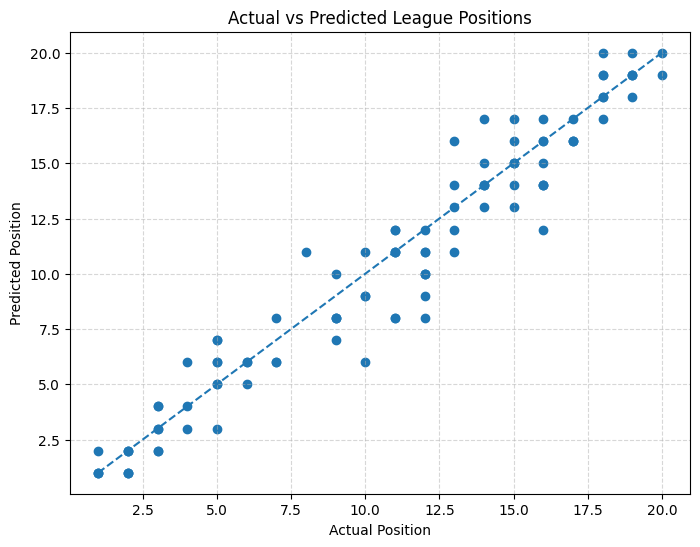

In [14]:
# Visualise predictions

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions)
plt.plot([1, 20], [1, 20], linestyle="--")

plt.title("Actual vs Predicted League Positions")
plt.xlabel("Actual Position")
plt.ylabel("Predicted Position")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [15]:
# Save best model

joblib.dump(rf_model, "../models/epl_random_forest_model.pkl")

print("Model saved.")

Model saved.


Model Comparison

In [16]:
# Compare model performance

model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae]
})

model_results = model_results.sort_values(by="MAE", ascending=True)

print(model_results)

               Model   MAE
1      Random Forest  1.03
0  Linear Regression  1.22


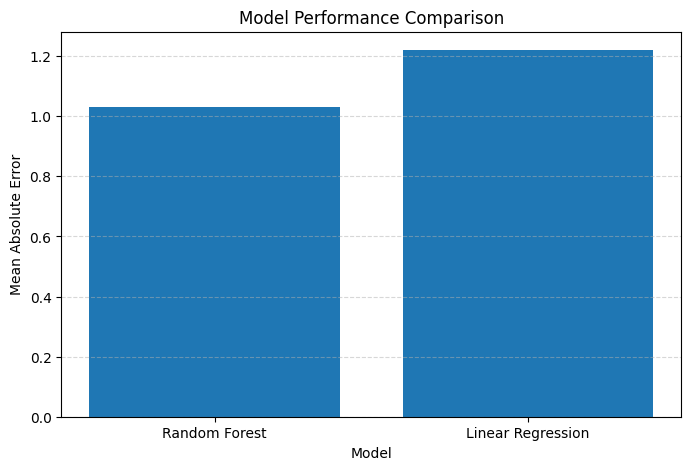

               Model   MAE
1      Random Forest  1.03
0  Linear Regression  1.22


In [20]:
# Plot model comparison

plt.figure(figsize=(8,5))

plt.bar(model_results["Model"], model_results["MAE"])

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae]
})

model_results = model_results.sort_values(
    by="MAE",
    ascending=True
)
print(model_results)